# JEPA Grokking: Prediction Accuracy & Memorization Dynamics

## The Missing Evidence

The original grokking notebook demonstrated that linear probe accuracy on the context encoder
rises from chance to 100% — but that only shows the *representation* becomes linearly separable.
It doesn't prove the **JEPA objective itself** generalized.

This notebook answers three critical questions:

**Experiment 1: Direct Prediction Accuracy**
Does the predictor actually output the correct target latent on unseen pairs?
If yes → genuine self-supervised grokking. If near chance → the JEPA loss only shaped
representations for a separate classifier, and "self-supervised grokking" needs qualification.

**Experiment 2: Memorization Dynamics in Latent Space**  
What's being memorized during the first phase? Track cosine similarity between
predictor output and target code on training vs validation pairs over time.
This directly visualizes the memorization → generalization transition in JEPA's own objective.

**Experiment 8 (bonus): Linear Probe vs Direct Prediction Timeline**  
Does linear probe accuracy rise before, after, or simultaneously with direct JEPA prediction?
This reveals whether the JEPA objective drives the solution or merely enables it.

### Key Hyperparameters
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| p | 97 | Prime, standard modular arithmetic task |
| train_frac | 0.3 | 30% train, 70% validation |
| latent_dim | 128 | Context/target latent dimension |
| hidden_dim | 256 | Encoder hidden layer width |
| predictor_dim | 64 | Predictor bottleneck |
| weight_decay | 1.0 | Strong regularization (enables grokking) |
| EMA decay | 0.996 | Target encoder momentum |
| epochs | 100,000 | Full training budget |
| eval_every | 500 | 200 evaluation checkpoints |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader

# ── Configuration ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Task
p = 97
train_frac = 0.3

# Architecture
LATENT_DIM = 128
HIDDEN_DIM = 256
PREDICTOR_DIM = 64

# Training
EPOCHS = 100_000
LR = 1e-3
WEIGHT_DECAY = 1.0
EMA_DECAY = 0.996

# Evaluation schedule: every 500 epochs → 200 checkpoints
EVAL_EVERY = 500

print(f'Task: (a+b) mod {p}')
print(f'Train fraction: {train_frac}')
print(f'Total epochs: {EPOCHS:,}')
print(f'Eval checkpoints: {EPOCHS // EVAL_EVERY}')

Device: cuda
Task: (a+b) mod 97
Train fraction: 0.3
Total epochs: 100,000
Eval checkpoints: 200


## Data Preparation

In [2]:
def generate_data(seed=SEED):
    pairs = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    targets = (pairs[:, 0] + pairs[:, 1]) % p
    n = len(pairs)
    n_train = int(train_frac * n)
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (
        pairs.to(device), targets.to(device),
        pairs[train_idx].to(device), targets[train_idx].to(device),
        pairs[val_idx].to(device), targets[val_idx].to(device),
    )

pairs, targets, train_pairs, train_targets, val_pairs, val_targets = generate_data(SEED)

n_train = len(train_pairs)
n_val = len(val_pairs)
print(f'Total pairs: {len(pairs)}')
print(f'Train: {n_train} ({n_train/len(pairs)*100:.1f}%)')
print(f'Val:   {n_val} ({n_val/len(pairs)*100:.1f}%)')
print(f'Chance accuracy: {100/p:.2f}%')

Total pairs: 9409
Train: 2822 (30.0%)
Val:   6587 (70.0%)
Chance accuracy: 1.03%


## Model Definitions

In [3]:
class ContextEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        e = e.view(e.size(0), -1)
        return F.normalize(self.net(e), dim=-1)

class TargetEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        return F.normalize(self.net(e), dim=-1)

class Predictor(nn.Module):
    def __init__(self, latent_dim, predictor_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, latent_dim),
        )
    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)

# Initialize
context_enc = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
target_enc  = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
predictor   = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)
target_enc_ema = deepcopy(target_enc)
for param in target_enc_ema.parameters():
    param.requires_grad = False

n_params = sum(p.numel() for p in context_enc.parameters())
n_params += sum(p.numel() for p in predictor.parameters())
n_params += sum(p.numel() for p in target_enc.parameters())
print(f'Total trainable parameters: {n_params:,}')

Total trainable parameters: 399,104


## Training with Full Diagnostic Tracking

At every evaluation checkpoint we compute:

1. **JEPA cosine similarity** between `z_pred` and `z_target` (train & val)
2. **Nearest-target-code accuracy** — does `argmax_c (z_pred · target_code[c]) == true_c`? (train & val)
3. **Linear probe accuracy** — closed-form ridge regression on context encoder (train & val)
4. **Wrong-code margin** — cosine distance to nearest *wrong* target code (train & val)

This is the complete picture. No post-hoc analysis needed — we see everything as it happens.

In [4]:
# ── Helper functions ───────────────────────────────────────────────────────

@torch.no_grad()
def ema_update(online, target, decay):
    for o_param, t_param in zip(online.parameters(), target.parameters()):
        t_param.data.mul_(decay).add_(o_param.data, alpha=1 - decay)

@torch.no_grad()
def linear_probe_accuracy(encoder, val_pairs, val_targets, train_pairs, train_targets, p):
    """Closed-form ridge regression probe."""
    z_train = encoder(train_pairs)
    z_val = encoder(val_pairs)
    y_train = F.one_hot(train_targets, num_classes=p).float()
    reg = 1e-3
    ZtZ = z_train.T @ z_train + reg * torch.eye(z_train.shape[1], device=device)
    ZtY = z_train.T @ y_train
    W = torch.linalg.solve(ZtZ, ZtY)
    train_acc = (z_train @ W).argmax(dim=1).eq(train_targets).float().mean().item()
    val_acc = (z_val @ W).argmax(dim=1).eq(val_targets).float().mean().item()
    return train_acc, val_acc

@torch.no_grad()
def jepa_diagnostics(context_enc, predictor, target_enc_ema, pairs, tgts):
    """Compute all JEPA-level metrics for a set of (input, target) pairs.
    
    Returns dict with:
      - cos_mean: mean cosine(z_pred, z_target) — the JEPA objective value
      - cos_std: std of per-sample cosine
      - nearest_code_acc: argmax_c (z_pred · code_c) == true_c
      - wrong_code_margin: cos(z_pred, correct_code) - cos(z_pred, nearest_wrong_code)
    """
    z_ctx = context_enc(pairs)
    z_pred = predictor(z_ctx)
    z_tgt = target_enc_ema(tgts)
    
    # 1. Cosine similarity (JEPA objective)
    cos_sim = (z_pred * z_tgt).sum(dim=-1)
    
    # 2. Nearest-target-code accuracy
    target_codes = target_enc_ema(torch.arange(p, device=device))  # (p, d)
    sim_to_all = z_pred @ target_codes.T  # (N, p)
    nearest_code_acc = sim_to_all.argmax(dim=1).eq(tgts).float().mean().item()
    
    # 3. Wrong-code margin
    # cos(z_pred, correct) - max_{c != correct} cos(z_pred, c)
    correct_sim = sim_to_all[torch.arange(len(tgts)), tgts]  # (N,)
    # Mask correct class with -inf to find best wrong class
    sim_masked = sim_to_all.clone()
    sim_masked[torch.arange(len(tgts)), tgts] = -float('inf')
    best_wrong_sim = sim_masked.max(dim=1).values  # (N,)
    margin = correct_sim - best_wrong_sim  # positive = correct class is closest
    
    return {
        'cos_mean': cos_sim.mean().item(),
        'cos_std': cos_sim.std().item(),
        'nearest_code_acc': nearest_code_acc,
        'margin_mean': margin.mean().item(),
        'margin_std': margin.std().item(),
        'frac_positive_margin': (margin > 0).float().mean().item(),
    }

In [5]:
# ── Training Loop ─────────────────────────────────────────────────────────

optimizer = optim.AdamW(
    list(context_enc.parameters()) + list(predictor.parameters()) + list(target_enc.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

train_loader = DataLoader(
    TensorDataset(train_pairs, train_targets),
    batch_size=len(train_pairs), shuffle=True
)

# Storage for all tracked metrics
history = {
    'epoch': [],
    'loss': [],
    # JEPA direct metrics (Exp 1 & 2)
    'train_cos_mean': [], 'train_cos_std': [],
    'val_cos_mean': [],   'val_cos_std': [],
    'train_nearest_acc': [], 'val_nearest_acc': [],
    'train_margin_mean': [], 'val_margin_mean': [],
    'train_margin_frac_pos': [], 'val_margin_frac_pos': [],
    # Linear probe (Exp 8)
    'train_probe_acc': [], 'val_probe_acc': [],
}

print(f'Training for {EPOCHS:,} epochs, evaluating every {EVAL_EVERY}...')
print(f'Expected eval points: {EPOCHS // EVAL_EVERY}')
print()

start_time = time.time()
last_print_time = start_time

for epoch in range(EPOCHS):
    context_enc.train()
    target_enc.train()
    predictor.train()
    
    for bp, bt in train_loader:
        optimizer.zero_grad()
        z_ctx = context_enc(bp)
        z_pred = predictor(z_ctx)
        with torch.no_grad():
            z_tgt = target_enc_ema(bt)
        loss = -(z_pred * z_tgt).sum(dim=-1).mean()
        loss.backward()
        optimizer.step()
        ema_update(target_enc, target_enc_ema, EMA_DECAY)
    
    # ── Evaluation checkpoint ──────────────────────────────────────────
    if epoch % EVAL_EVERY == 0 or epoch == EPOCHS - 1:
        context_enc.eval()
        target_enc.eval()
        predictor.eval()
        
        # JEPA direct metrics
        train_diag = jepa_diagnostics(context_enc, predictor, target_enc_ema,
                                      train_pairs, train_targets)
        val_diag = jepa_diagnostics(context_enc, predictor, target_enc_ema,
                                    val_pairs, val_targets)
        
        # Linear probe
        train_probe, val_probe = linear_probe_accuracy(
            context_enc, val_pairs, val_targets, train_pairs, train_targets, p)
        
        # Store everything
        history['epoch'].append(epoch)
        history['loss'].append(loss.item())
        
        history['train_cos_mean'].append(train_diag['cos_mean'])
        history['train_cos_std'].append(train_diag['cos_std'])
        history['val_cos_mean'].append(val_diag['cos_mean'])
        history['val_cos_std'].append(val_diag['cos_std'])
        
        history['train_nearest_acc'].append(train_diag['nearest_code_acc'])
        history['val_nearest_acc'].append(val_diag['nearest_code_acc'])
        
        history['train_margin_mean'].append(train_diag['margin_mean'])
        history['val_margin_mean'].append(val_diag['margin_mean'])
        history['train_margin_frac_pos'].append(train_diag['frac_positive_margin'])
        history['val_margin_frac_pos'].append(val_diag['frac_positive_margin'])
        
        history['train_probe_acc'].append(train_probe)
        history['val_probe_acc'].append(val_probe)
        
        # Print periodically (not every checkpoint — too noisy)
        now = time.time()
        if epoch % (EVAL_EVERY * 10) == 0 or epoch == EPOCHS - 1:
            elapsed = (now - start_time) / 60
            print(f'Epoch {epoch:6d} [{elapsed:5.1f}m] | '
                  f'Loss {loss.item():+.4f} | '
                  f'JEPA cos: train={train_diag["cos_mean"]:.3f} val={val_diag["cos_mean"]:.3f} | '
                  f'Nearest: train={train_diag["nearest_code_acc"]*100:.1f}% val={val_diag["nearest_code_acc"]*100:.1f}% | '
                  f'Probe: train={train_probe*100:.1f}% val={val_probe*100:.1f}%')

elapsed_total = (time.time() - start_time) / 60
print(f'\nTraining complete in {elapsed_total:.1f} minutes.')
print(f'Collected {len(history["epoch"])} evaluation checkpoints.')

Training for 100,000 epochs, evaluating every 500...
Expected eval points: 200

Epoch      0 [  0.0m] | Loss -0.0163 | JEPA cos: train=0.038 val=0.037 | Nearest: train=1.1% val=1.0% | Probe: train=23.0% val=0.1%
Epoch   5000 [  2.5m] | Loss -0.8652 | JEPA cos: train=0.887 val=0.169 | Nearest: train=100.0% val=0.9% | Probe: train=99.9% val=0.4%
Epoch  10000 [  5.1m] | Loss -0.8842 | JEPA cos: train=0.890 val=0.205 | Nearest: train=100.0% val=2.1% | Probe: train=100.0% val=0.9%
Epoch  15000 [  7.6m] | Loss -0.8482 | JEPA cos: train=0.822 val=0.256 | Nearest: train=99.8% val=4.0% | Probe: train=99.9% val=1.9%
Epoch  20000 [ 10.1m] | Loss -0.8863 | JEPA cos: train=0.893 val=0.299 | Nearest: train=100.0% val=7.3% | Probe: train=100.0% val=4.4%
Epoch  25000 [ 12.7m] | Loss -0.8771 | JEPA cos: train=0.875 val=0.342 | Nearest: train=100.0% val=12.9% | Probe: train=100.0% val=10.4%
Epoch  30000 [ 15.2m] | Loss -0.9346 | JEPA cos: train=0.930 val=0.436 | Nearest: train=100.0% val=26.6% | Probe: 

In [6]:
# Save checkpoint and history for reproducibility
torch.save({
    'context_enc': context_enc.state_dict(),
    'target_enc_ema': target_enc_ema.state_dict(),
    'predictor': predictor.state_dict(),
    'history': history,
}, 'jepa_grokking_checkpoint.pt')
print('Checkpoint saved: jepa_grokking_checkpoint.pt')

Checkpoint saved: jepa_grokking_checkpoint.pt


## Experiment 2: Memorization Dynamics in Latent Space

This is the key visualization. We plot the JEPA objective (cosine similarity between
predictor output and target code) on training vs validation pairs over the full training run.

**What we expect to see:**
- **Early:** training cosine high, validation cosine low → predictor memorizes training pairs
- **Late:** both high → predictor generalizes to the full equivalence class structure
- **The gap closing** is the grokking event in JEPA's own objective space

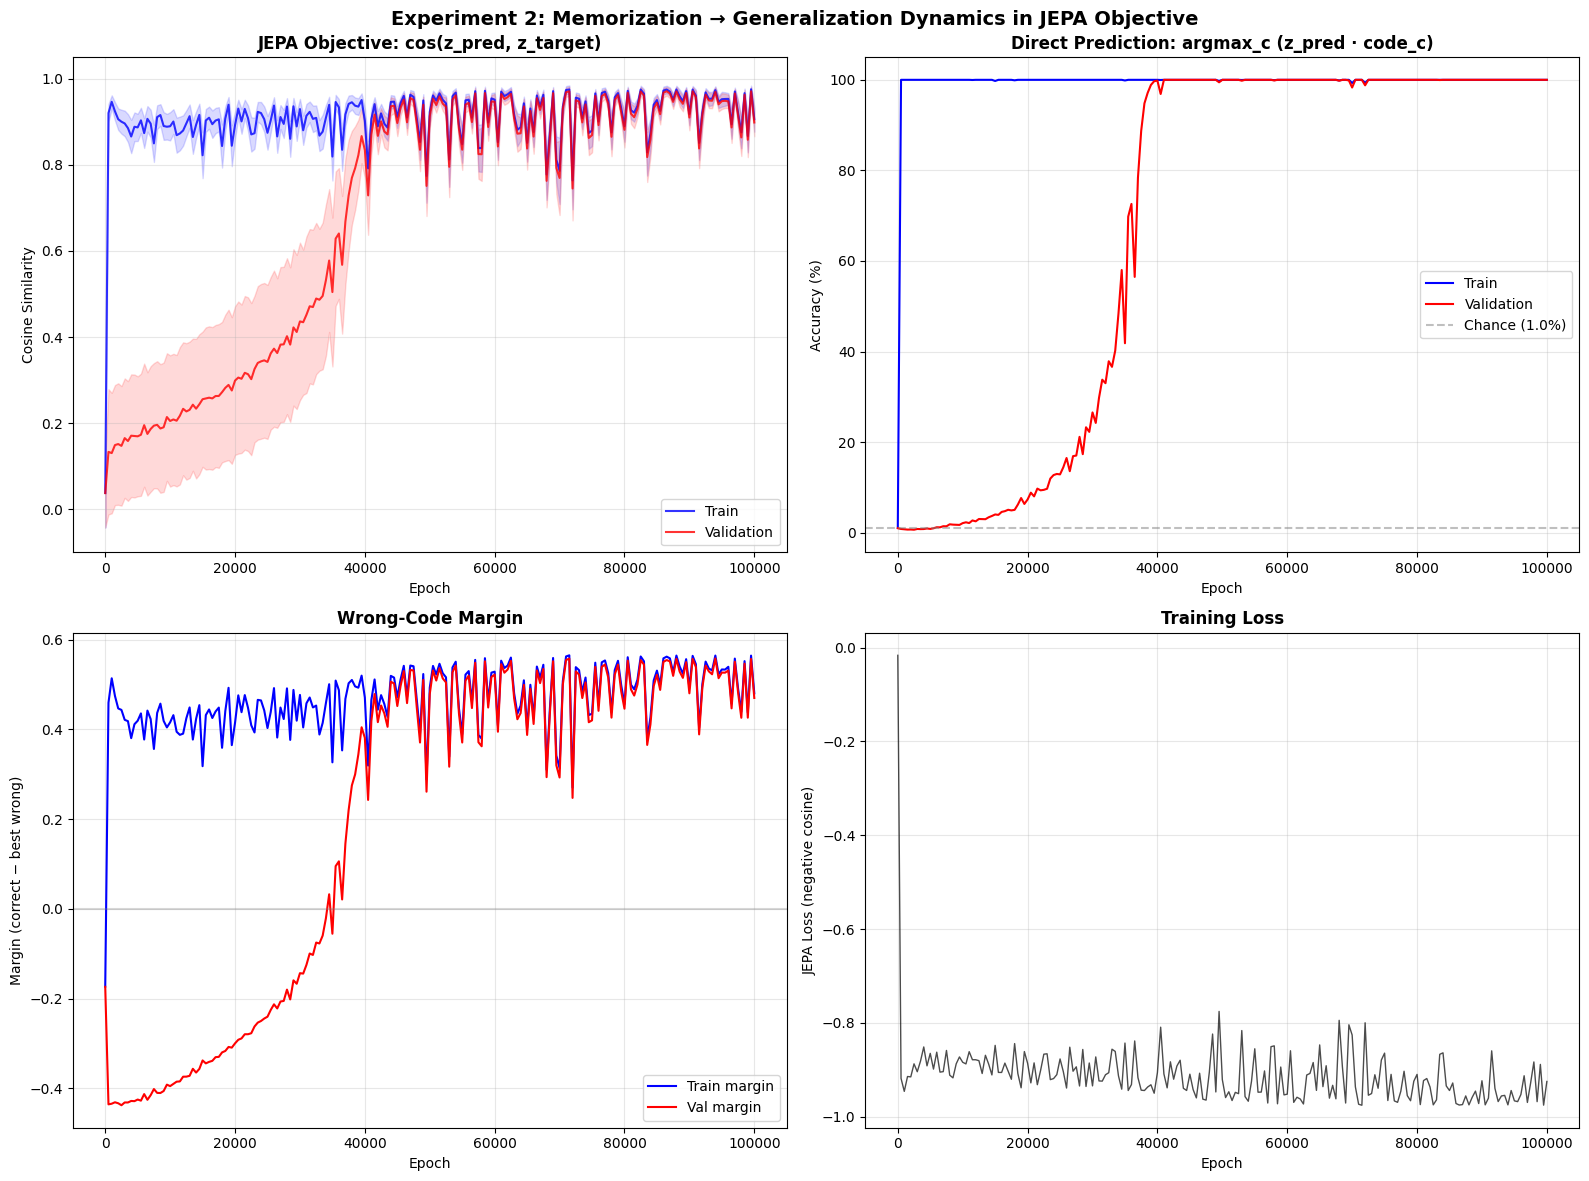


Grokking event (val nearest-code acc > 90%): epoch 38000
  At grokking:
    Train cos:  0.9456
    Val cos:    0.7700
    Train acc:  100.0%
    Val acc:    94.8%
    Train margin: 0.5104
    Val margin:   0.2753


In [7]:
epochs = np.array(history['epoch'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Panel 1: JEPA Cosine Similarity (the objective) ─────────────────────
ax = axes[0, 0]
ax.plot(epochs, history['train_cos_mean'], 'b-', linewidth=1.5, label='Train', alpha=0.8)
ax.plot(epochs, history['val_cos_mean'], 'r-', linewidth=1.5, label='Validation', alpha=0.8)
# Shade ±1σ
train_upper = np.array(history['train_cos_mean']) + np.array(history['train_cos_std'])
train_lower = np.array(history['train_cos_mean']) - np.array(history['train_cos_std'])
val_upper = np.array(history['val_cos_mean']) + np.array(history['val_cos_std'])
val_lower = np.array(history['val_cos_mean']) - np.array(history['val_cos_std'])
ax.fill_between(epochs, train_lower, train_upper, alpha=0.15, color='blue')
ax.fill_between(epochs, val_lower, val_upper, alpha=0.15, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cosine Similarity')
ax.set_title('JEPA Objective: cos(z_pred, z_target)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.1, 1.05)

# ── Panel 2: Nearest Target Code Accuracy ──────────────────────────────
ax = axes[0, 1]
ax.plot(epochs, [a*100 for a in history['train_nearest_acc']], 'b-', linewidth=1.5, label='Train')
ax.plot(epochs, [a*100 for a in history['val_nearest_acc']], 'r-', linewidth=1.5, label='Validation')
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.5, label=f'Chance ({100/p:.1f}%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Direct Prediction: argmax_c (z_pred · code_c)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 3: Wrong-Code Margin ─────────────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs, history['train_margin_mean'], 'b-', linewidth=1.5, label='Train margin')
ax.plot(epochs, history['val_margin_mean'], 'r-', linewidth=1.5, label='Val margin')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Margin (correct − best wrong)')
ax.set_title('Wrong-Code Margin', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 4: Loss curve ────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(epochs, history['loss'], 'k-', linewidth=1, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('JEPA Loss (negative cosine)')
ax.set_title('Training Loss', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Experiment 2: Memorization → Generalization Dynamics in JEPA Objective',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp2_memorization_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Find the grokking transition ───────────────────────────────────────
val_acc_arr = np.array(history['val_nearest_acc'])
train_acc_arr = np.array(history['train_nearest_acc'])

# Grokking epoch: first time val nearest-code accuracy exceeds 90%
grok_mask = val_acc_arr > 0.9
if grok_mask.any():
    grok_epoch = epochs[grok_mask][0]
    grok_idx = np.where(grok_mask)[0][0]
    print(f'\nGrokking event (val nearest-code acc > 90%): epoch {grok_epoch}')
    print(f'  At grokking:')
    print(f'    Train cos:  {history["train_cos_mean"][grok_idx]:.4f}')
    print(f'    Val cos:    {history["val_cos_mean"][grok_idx]:.4f}')
    print(f'    Train acc:  {train_acc_arr[grok_idx]*100:.1f}%')
    print(f'    Val acc:    {val_acc_arr[grok_idx]*100:.1f}%')
    print(f'    Train margin: {history["train_margin_mean"][grok_idx]:.4f}')
    print(f'    Val margin:   {history["val_margin_mean"][grok_idx]:.4f}')
else:
    grok_epoch = None
    print('\nNo grokking detected (val nearest-code acc never exceeded 90%)')

## Experiment 2b: Zoomed Dynamics Around Grokking Transition

Zoom into the window around the grokking event to see the fine-grained transition dynamics.

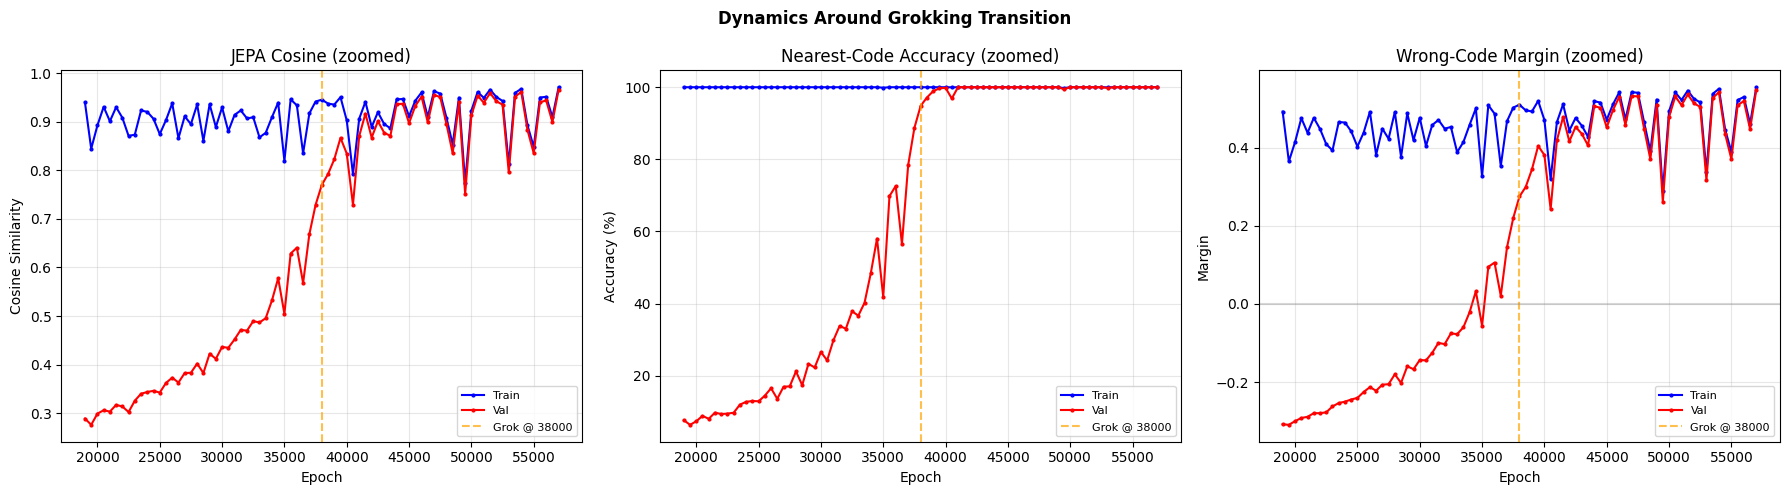

In [8]:
if grok_epoch is not None:
    # Zoom window: 20% before grokking to 20% after (or end of training)
    window_before = int(grok_epoch * 0.5)
    window_after = min(int(grok_epoch * 1.5), EPOCHS)
    mask = (epochs >= grok_epoch - window_before) & (epochs <= window_after)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # JEPA cosine zoom
    ax = axes[0]
    ax.plot(epochs[mask], np.array(history['train_cos_mean'])[mask], 'b-o', markersize=2, label='Train')
    ax.plot(epochs[mask], np.array(history['val_cos_mean'])[mask], 'r-o', markersize=2, label='Val')
    ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title('JEPA Cosine (zoomed)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Nearest-code accuracy zoom
    ax = axes[1]
    ax.plot(epochs[mask], train_acc_arr[mask]*100, 'b-o', markersize=2, label='Train')
    ax.plot(epochs[mask], val_acc_arr[mask]*100, 'r-o', markersize=2, label='Val')
    ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Nearest-Code Accuracy (zoomed)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Margin zoom
    ax = axes[2]
    ax.plot(epochs[mask], np.array(history['train_margin_mean'])[mask], 'b-o', markersize=2, label='Train')
    ax.plot(epochs[mask], np.array(history['val_margin_mean'])[mask], 'r-o', markersize=2, label='Val')
    ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Margin')
    ax.set_title('Wrong-Code Margin (zoomed)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    plt.suptitle('Dynamics Around Grokking Transition', fontweight='bold')
    plt.tight_layout()
    plt.savefig('exp2_grokking_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping zoom plot — no grokking detected.')

## Experiment 1: Direct JEPA Prediction Accuracy (Final Model)

Detailed analysis of the trained model's direct prediction quality.
This is the definitive test: does `z_pred` actually land on the correct target code?

In [9]:
context_enc.eval()
predictor.eval()
target_enc_ema.eval()

with torch.no_grad():
    # Validation set
    z_ctx_val = context_enc(val_pairs)
    z_pred_val = predictor(z_ctx_val)
    z_tgt_val = target_enc_ema(val_targets)
    
    cos_sim_val = (z_pred_val * z_tgt_val).sum(dim=-1)
    
    # All target codes
    target_codes = target_enc_ema(torch.arange(p, device=device))
    sim_to_all = z_pred_val @ target_codes.T
    
    # Nearest-code accuracy
    nearest_acc = sim_to_all.argmax(dim=1).eq(val_targets).float().mean().item()
    
    # Top-k accuracy
    topk_idx = sim_to_all.topk(5, dim=1).indices
    top3_acc = (topk_idx[:, :3] == val_targets.unsqueeze(1)).any(dim=1).float().mean().item()
    top5_acc = (topk_idx[:, :5] == val_targets.unsqueeze(1)).any(dim=1).float().mean().item()
    
    # Margin statistics
    correct_sim = sim_to_all[torch.arange(n_val), val_targets]
    sim_masked = sim_to_all.clone()
    sim_masked[torch.arange(n_val), val_targets] = -float('inf')
    best_wrong_sim = sim_masked.max(dim=1).values
    margin = correct_sim - best_wrong_sim

print('='*60)
print('EXPERIMENT 1: Direct JEPA Prediction Accuracy')
print('='*60)
print(f'\nValidation set ({n_val} pairs):')
print(f'  Cosine similarity (z_pred, z_target):')
print(f'    Mean: {cos_sim_val.mean().item():.4f} ± {cos_sim_val.std().item():.4f}')
print(f'    Min:  {cos_sim_val.min().item():.4f}')
print(f'    >0.9:  {(cos_sim_val > 0.9).float().mean().item()*100:.2f}%')
print(f'    >0.95: {(cos_sim_val > 0.95).float().mean().item()*100:.2f}%')
print(f'    >0.99: {(cos_sim_val > 0.99).float().mean().item()*100:.2f}%')
print(f'\n  Nearest-code accuracy (argmax_c z_pred·code_c):')
print(f'    Top-1: {nearest_acc*100:.2f}%')
print(f'    Top-3: {top3_acc*100:.2f}%')
print(f'    Top-5: {top5_acc*100:.2f}%')
print(f'\n  Margin (correct − best wrong):')
print(f'    Mean:   {margin.mean().item():.4f} ± {margin.std().item():.4f}')
print(f'    Min:    {margin.min().item():.4f}')
print(f'    All positive: {(margin > 0).all().item()}')

# ── Verdict ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
if nearest_acc > 0.95:
    print('VERDICT: GENUINE self-supervised grokking.')
    print('The JEPA objective itself generalizes — the predictor directly')
    print('produces the correct target latent for unseen (a,b) pairs.')
elif nearest_acc > 0.5:
    print('VERDICT: PARTIAL generalization.')
    print('The predictor shows significant but imperfect direct prediction.')
else:
    print('VERDICT: NO direct generalization.')
    print('The JEPA loss only shaped representations for a separate classifier.')
    print('"Self-supervised grokking" needs qualification.')
print('='*60)

EXPERIMENT 1: Direct JEPA Prediction Accuracy

Validation set (6587 pairs):
  Cosine similarity (z_pred, z_target):
    Mean: 0.8986 ± 0.0321
    Min:  0.7177
    >0.9:  54.56%
    >0.95: 0.70%
    >0.99: 0.00%

  Nearest-code accuracy (argmax_c z_pred·code_c):
    Top-1: 100.00%
    Top-3: 100.00%
    Top-5: 100.00%

  Margin (correct − best wrong):
    Mean:   0.4703 ± 0.0637
    Min:    0.2446
    All positive: True

VERDICT: GENUINE self-supervised grokking.
The JEPA objective itself generalizes — the predictor directly
produces the correct target latent for unseen (a,b) pairs.


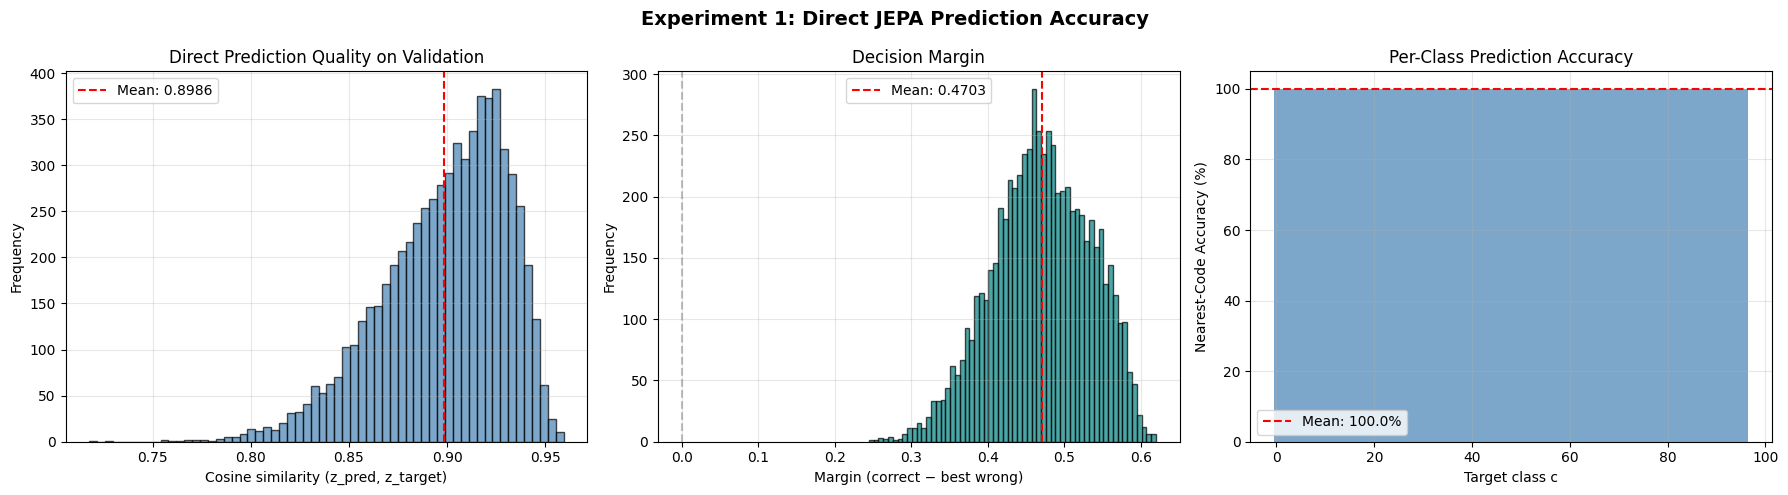

In [10]:
# ── Experiment 1: Detailed Visualizations ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cosine similarity histogram
ax = axes[0]
ax.hist(cos_sim_val.cpu().numpy(), bins=60, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(cos_sim_val.mean().item(), color='red', linestyle='--',
           label=f'Mean: {cos_sim_val.mean().item():.4f}')
ax.set_xlabel('Cosine similarity (z_pred, z_target)')
ax.set_ylabel('Frequency')
ax.set_title('Direct Prediction Quality on Validation')
ax.legend()
ax.grid(alpha=0.3)

# Margin histogram
ax = axes[1]
margin_np = margin.cpu().numpy()
ax.hist(margin_np, bins=60, alpha=0.7, color='teal', edgecolor='black')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(margin_np.mean(), color='red', linestyle='--',
           label=f'Mean: {margin_np.mean():.4f}')
ax.set_xlabel('Margin (correct − best wrong)')
ax.set_ylabel('Frequency')
ax.set_title('Decision Margin')
ax.legend()
ax.grid(alpha=0.3)

# Per-class accuracy
ax = axes[2]
per_class_acc = []
for c in range(p):
    mask = val_targets == c
    if mask.sum() > 0:
        acc_c = sim_to_all[mask].argmax(dim=1).eq(c).float().mean().item()
        per_class_acc.append(acc_c)
    else:
        per_class_acc.append(0.0)
ax.bar(range(p), [a*100 for a in per_class_acc], color='steelblue', alpha=0.7, width=1.0)
ax.axhline(y=np.mean(per_class_acc)*100, color='red', linestyle='--',
           label=f'Mean: {np.mean(per_class_acc)*100:.1f}%')
ax.set_xlabel('Target class c')
ax.set_ylabel('Nearest-Code Accuracy (%)')
ax.set_title('Per-Class Prediction Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Experiment 1: Direct JEPA Prediction Accuracy', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp1_direct_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## Experiment 8 (Bonus): Linear Probe vs Direct Prediction Timeline

The definitive comparison: does the representation become linearly separable BEFORE
the predictor can directly hit targets? Or do they rise together?

**Interpretation:**
- **Probe first** → representation generalizes, predictor follows
- **Together** → JEPA objective directly drives generalization
- **Prediction first** → predictor generalizes before the encoder representation is clean

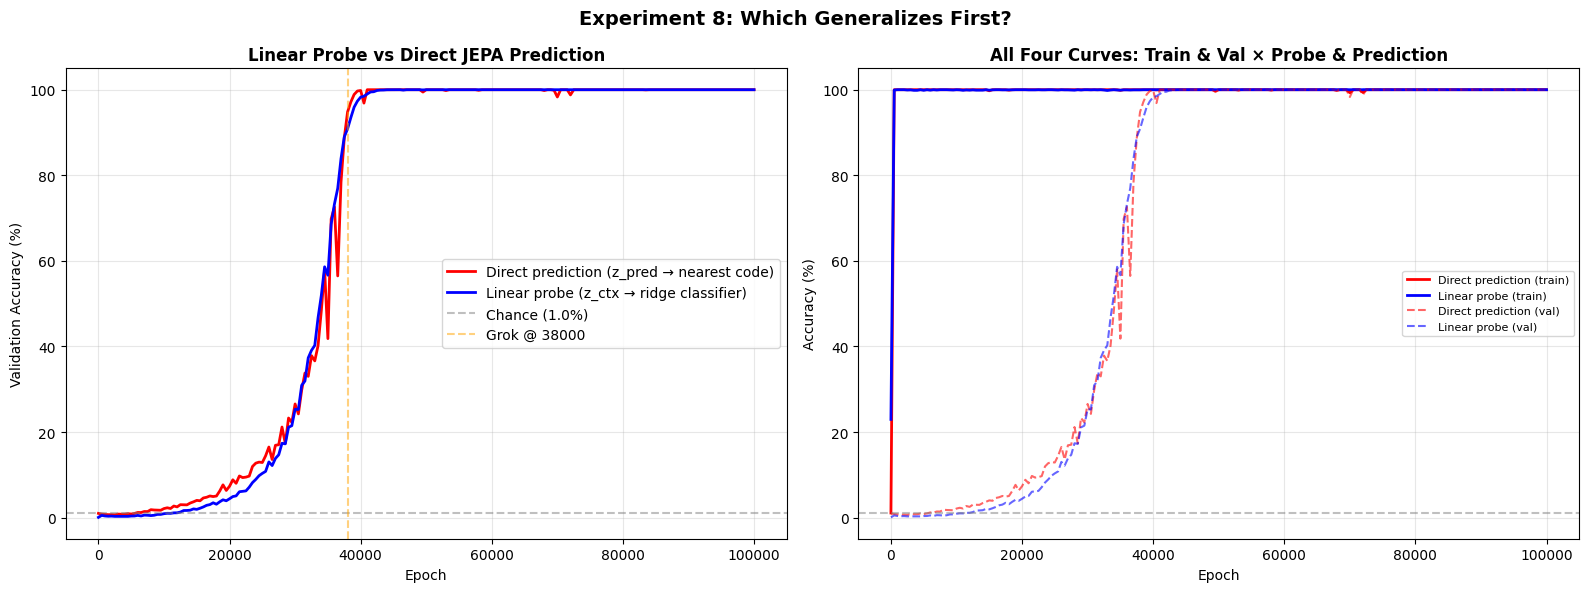


Timeline: When does each metric cross threshold?
 Threshold |  Probe epoch |  Predict epoch |        Lag
-----------+--------------+----------------+-----------
       50% |        34000 |          34500 |       +500
       80% |        37000 |          37500 |       +500
       90% |        38000 |          38000 |         +0
       95% |        39000 |          38500 |       -500
       99% |        41500 |          39500 |      -2000

→ Direct prediction rises FIRST
  The predictor generalizes before the context encoder is linearly separable.
  This would be surprising and worth investigating further.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Validation accuracy — both metrics ─────────────────────────
ax = axes[0]
ax.plot(epochs, [a*100 for a in history['val_nearest_acc']],
        'r-', linewidth=2, label='Direct prediction (z_pred → nearest code)')
ax.plot(epochs, [a*100 for a in history['val_probe_acc']],
        'b-', linewidth=2, label='Linear probe (z_ctx → ridge classifier)')
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.5, label=f'Chance ({100/p:.1f}%)')
if grok_epoch is not None:
    ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.5, label=f'Grok @ {grok_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Linear Probe vs Direct JEPA Prediction', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Train accuracy — both metrics ─────────────────────────────
ax = axes[1]
ax.plot(epochs, [a*100 for a in history['train_nearest_acc']],
        'r-', linewidth=2, label='Direct prediction (train)')
ax.plot(epochs, [a*100 for a in history['train_probe_acc']],
        'b-', linewidth=2, label='Linear probe (train)')
ax.plot(epochs, [a*100 for a in history['val_nearest_acc']],
        'r--', linewidth=1.5, alpha=0.6, label='Direct prediction (val)')
ax.plot(epochs, [a*100 for a in history['val_probe_acc']],
        'b--', linewidth=1.5, alpha=0.6, label='Linear probe (val)')
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('All Four Curves: Train & Val × Probe & Prediction', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Experiment 8: Which Generalizes First?', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp8_probe_vs_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantify the lag ───────────────────────────────────────────────────
probe_arr = np.array(history['val_probe_acc'])
pred_arr = np.array(history['val_nearest_acc'])

thresholds = [0.5, 0.8, 0.9, 0.95, 0.99]
print('\nTimeline: When does each metric cross threshold?')
print(f'{"Threshold":>10s} | {"Probe epoch":>12s} | {"Predict epoch":>14s} | {"Lag":>10s}')
print(f'{"-"*10}-+-{"-"*12}-+-{"-"*14}-+-{"-"*10}')
for thr in thresholds:
    probe_cross = epochs[probe_arr >= thr]
    pred_cross = epochs[pred_arr >= thr]
    ep_probe = probe_cross[0] if len(probe_cross) > 0 else None
    ep_pred = pred_cross[0] if len(pred_cross) > 0 else None
    
    ep_probe_str = f'{ep_probe:>12d}' if ep_probe is not None else f'{"never":>12s}'
    ep_pred_str = f'{ep_pred:>14d}' if ep_pred is not None else f'{"never":>14s}'
    
    if ep_probe is not None and ep_pred is not None:
        lag = ep_pred - ep_probe
        lag_str = f'{lag:>+10d}'
    else:
        lag_str = f'{"N/A":>10s}'
    
    print(f'{thr:>10.0%} | {ep_probe_str} | {ep_pred_str} | {lag_str}')

print()
if ep_probe is not None and ep_pred is not None:
    if abs(epochs[1] - epochs[0]) >= abs(ep_pred - ep_probe):
        print('→ Probe and direct prediction rise SIMULTANEOUSLY')
        print('  The JEPA objective directly drives the solution.')
    elif ep_probe < ep_pred:
        print('→ Linear probe rises FIRST')
        print('  The representation becomes separable before the predictor can hit targets.')
        print('  The predictor catches up as the target codes stabilize.')
    else:
        print('→ Direct prediction rises FIRST')
        print('  The predictor generalizes before the context encoder is linearly separable.')
        print('  This would be surprising and worth investigating further.')

## Combined Summary

In [12]:
print('='*70)
print('SUMMARY: JEPA Grokking — Prediction Accuracy & Dynamics')
print('='*70)

print(f'\n--- Experiment 1: Direct Prediction Accuracy ---')
print(f'  Cosine(z_pred, z_target) on validation:')
print(f'    Mean: {cos_sim_val.mean().item():.4f} ± {cos_sim_val.std().item():.4f}')
print(f'  Nearest-code accuracy on validation:')
print(f'    Top-1: {nearest_acc*100:.2f}%')
print(f'  Margin (correct − best wrong):')
print(f'    Mean: {margin.mean().item():.4f}, all positive: {(margin > 0).all().item()}')
if nearest_acc > 0.95:
    print(f'  ✓ GENUINE self-supervised grokking confirmed.')
else:
    print(f'  ✗ Direct prediction insufficient — grokking claim needs qualification.')

print(f'\n--- Experiment 2: Memorization Dynamics ---')
if grok_epoch is not None:
    # Find memorization phase: when train nearest acc > 90% but val < 10%
    mem_mask = (train_acc_arr > 0.9) & (val_acc_arr < 0.1)
    if mem_mask.any():
        mem_start = epochs[mem_mask][0]
        mem_end = epochs[mem_mask][-1]
        print(f'  Memorization phase: epoch {mem_start} – {mem_end}')
        print(f'    (train acc >90% while val acc <10%)')
    else:
        print(f'  No clear memorization phase detected.')
    print(f'  Grokking transition: epoch {grok_epoch}')
    print(f'  Final state:')
    print(f'    Train cos: {history["train_cos_mean"][-1]:.4f}')
    print(f'    Val cos:   {history["val_cos_mean"][-1]:.4f}')
    print(f'    Gap:       {history["train_cos_mean"][-1] - history["val_cos_mean"][-1]:.4f}')
else:
    print(f'  No grokking detected within {EPOCHS} epochs.')

print(f'\n--- Experiment 8: Probe vs Prediction Timeline ---')
final_probe = history['val_probe_acc'][-1]
final_pred = history['val_nearest_acc'][-1]
print(f'  Final linear probe accuracy:     {final_probe*100:.2f}%')
print(f'  Final direct prediction accuracy: {final_pred*100:.2f}%')

print(f'\n{"="*70}')

SUMMARY: JEPA Grokking — Prediction Accuracy & Dynamics

--- Experiment 1: Direct Prediction Accuracy ---
  Cosine(z_pred, z_target) on validation:
    Mean: 0.8986 ± 0.0321
  Nearest-code accuracy on validation:
    Top-1: 100.00%
  Margin (correct − best wrong):
    Mean: 0.4703, all positive: True
  ✓ GENUINE self-supervised grokking confirmed.

--- Experiment 2: Memorization Dynamics ---
  Memorization phase: epoch 500 – 23000
    (train acc >90% while val acc <10%)
  Grokking transition: epoch 38000
  Final state:
    Train cos: 0.9063
    Val cos:   0.8986
    Gap:       0.0076

--- Experiment 8: Probe vs Prediction Timeline ---
  Final linear probe accuracy:     100.00%
  Final direct prediction accuracy: 100.00%

